# 我的第一个 GNN 实验（Cora 节点分类）

## 实验目的
熟悉 PyTorch、PyG 以及 Jupyter 的基本使用。

## 实验步骤
1. **环境搭建**：在 WSL Ubuntu 中配置了 Anaconda 和 `gnn_env` 环境。
2. **数据加载**：使用 PyG 加载了经典的 Cora 引用网络数据集。
3. **模型定义**：搭建了一个两层图卷积网络（GCN）。
4. **模型训练**：在 GPU 上训练了 100 个 Epoch，测试准确率达到了 **80%** 左右。

> 注意：我的显卡是 RTX 3050 Ti（4GB 显存），跑小图完全没问题。

*实验日期：2026年9月12日*

In [8]:
import torch

# 1. 创建一个简单的张量 (Tensor)
x = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
print("创建的张量:\n", x)

# 2. 测试 GPU 是否可用
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"当前使用的计算设备: {device}")
if device.type == 'cuda':
    print(f"显卡型号: {torch.cuda.get_device_name(0)}")

# 3. 把张量移动到 GPU 上计算
x_gpu = x.to(device)
y_gpu = x_gpu * 2 + 1  # 在 GPU 上进行矩阵运算
print("在 GPU 上计算后的结果:\n", y_gpu.cpu()) # 移回 CPU 才能打印

创建的张量:
 tensor([[1., 2.],
        [3., 4.]])
当前使用的计算设备: cuda
显卡型号: NVIDIA GeForce RTX 3050 Ti Laptop GPU
在 GPU 上计算后的结果:
 tensor([[3., 5.],
        [7., 9.]])


In [9]:
# 1. 彻底清空之前可能损坏的文件
!rm -rf /tmp/Cora
!mkdir -p /tmp/Cora/raw

# 2. 使用 Gitee 镜像下载（这个源在国内非常快，且稳定）
!cd /tmp/Cora/raw && wget -q --show-progress https://gitee.com/jiaxiaochu/planetoid/raw/master/data/ind.cora.x
!cd /tmp/Cora/raw && wget -q --show-progress https://gitee.com/jiaxiaochu/planetoid/raw/master/data/ind.cora.y
!cd /tmp/Cora/raw && wget -q --show-progress https://gitee.com/jiaxiaochu/planetoid/raw/master/data/ind.cora.tx
!cd /tmp/Cora/raw && wget -q --show-progress https://gitee.com/jiaxiaochu/planetoid/raw/master/data/ind.cora.ty
!cd /tmp/Cora/raw && wget -q --show-progress https://gitee.com/jiaxiaochu/planetoid/raw/master/data/ind.cora.allx
!cd /tmp/Cora/raw && wget -q --show-progress https://gitee.com/jiaxiaochu/planetoid/raw/master/data/ind.cora.ally
!cd /tmp/Cora/raw && wget -q --show-progress https://gitee.com/jiaxiaochu/planetoid/raw/master/data/ind.cora.graph
!cd /tmp/Cora/raw && wget -q --show-progress https://gitee.com/jiaxiaochu/planetoid/raw/master/data/ind.cora.test.index

In [10]:
from torch_geometric.datasets import Planetoid

# 1. 加载 Cora 数据集 (直接读取本地 /tmp/Cora)
dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0] # 获取图数据对象

print(f"数据集信息: {dataset}")
print("====================================")

# 2. 探索图的结构
print(f"图包含的节点数 (论文数): {data.num_nodes}")
print(f"图包含的边数 (引用关系): {data.num_edges}")
print(f"每个节点的特征维度 (词向量长度): {dataset.num_node_features}")
print(f"节点分类的类别数 (论文主题数): {dataset.num_classes}")
print(f"用于训练的节点数: {data.train_mask.sum().item()}")
print("====================================")

# 3. 看看节点的特征长什么样
print("前 5 个节点的特征矩阵形状:", data.x[:5].shape)
print("边索引 (edge_index) 的形状 [2, 边数]:", data.edge_index.shape)

/home/wangziyan/anaconda3/envs/gnn_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


数据集信息: Cora()
图包含的节点数 (论文数): 2708
图包含的边数 (引用关系): 10556
每个节点的特征维度 (词向量长度): 1433
节点分类的类别数 (论文主题数): 7
用于训练的节点数: 140
前 5 个节点的特征矩阵形状: torch.Size([5, 1433])
边索引 (edge_index) 的形状 [2, 边数]: torch.Size([2, 10556])


Processing...
Done!


In [12]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

# 定义一个简单的两层图卷积网络 (GCN)
class SimpleGCN(torch.nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super().__init__()
        # 第一层图卷积：把输入特征映射到隐藏层
        self.conv1 = GCNConv(num_features, hidden_channels)
        # 第二层图卷积：把隐藏层映射到分类数
        self.conv2 = GCNConv(hidden_channels, num_classes)

    def forward(self, x, edge_index):
        # 1. 第一层卷积 + 激活函数
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        # 2. 第二层卷积
        x = self.conv2(x, edge_index)
        # 3. 输出 log_softmax 用于分类
        return F.log_softmax(x, dim=1)

# 实例化模型，并移动到 GPU
model = SimpleGCN(
    num_features=dataset.num_node_features, 
    hidden_channels=16, # 隐藏层设小一点，适应你的 4GB 显存
    num_classes=dataset.num_classes
).to(device)

print(model) # 打印模型结构-

SimpleGCN(
  (conv1): GCNConv(1433, 16)
  (conv2): GCNConv(16, 7)
)


In [13]:
# 1. 把图数据移动到 GPU（Cora 很小，4GB 显存毫无压力）
data = data.to(device)

# 2. 定义优化器和损失函数
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

# 3. 训练函数
def train():
    model.train()
    optimizer.zero_grad() # 清空梯度
    out = model(data.x, data.edge_index) # 前向传播
    loss = criterion(out[data.train_mask], data.y[data.train_mask]) # 只计算训练节点的损失
    loss.backward() # 反向传播
    optimizer.step() # 更新参数
    return loss

# 4. 测试函数
def test():
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1) # 取概率最大的类别
    test_correct = pred[data.test_mask] == data.y[data.test_mask]
    test_acc = int(test_correct.sum()) / int(data.test_mask.sum())
    return test_acc

# 5. 开始跑 100 个 Epoch
print("开始训练...")
for epoch in range(1, 101):
    loss = train()
    if epoch % 20 == 0:
        acc = test()
        print(f"Epoch: {epoch:03d}, Loss: {loss:.4f}, Test Acc: {acc:.4f}")

print("训练结束！")

开始训练...
Epoch: 020, Loss: 0.2470, Test Acc: 0.8010
Epoch: 040, Loss: 0.0628, Test Acc: 0.7960
Epoch: 060, Loss: 0.0448, Test Acc: 0.8000
Epoch: 080, Loss: 0.0332, Test Acc: 0.7990
Epoch: 100, Loss: 0.0345, Test Acc: 0.8030
训练结束！


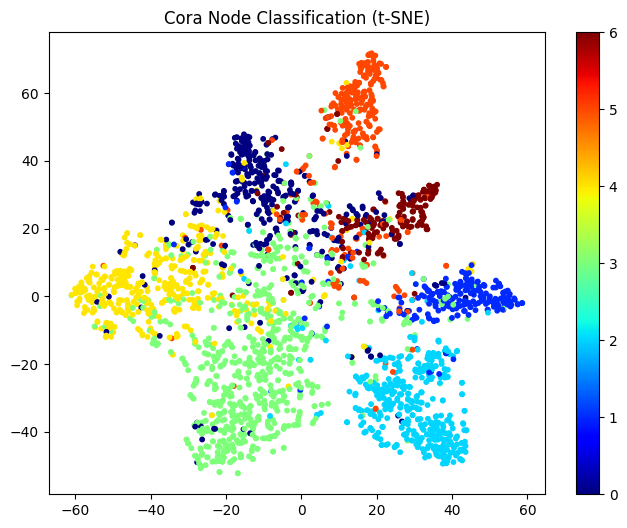

In [15]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 获取模型倒数第二层的输出（即隐藏层特征）
model.eval()
with torch.no_grad():
    # 我们手动调用第一层来获取嵌入
    x_embed = model.conv1(data.x, data.edge_index)
    x_embed = x_embed.cpu().numpy()

# 用 t-SNE 把 16 维特征降维到 2 维，方便画图
tsne = TSNE(n_components=2, random_state=42)
x_2d = tsne.fit_transform(x_embed)

# 画图
plt.figure(figsize=(8, 6))
plt.scatter(x_2d[:, 0], x_2d[:, 1], c=data.y.cpu().numpy(), cmap='jet', s=10)
plt.colorbar()
plt.title("Cora Node Classification (t-SNE)")
plt.show()